# Day 32 | PM Session – Decision Trees & Random Forest: Applied
**Week 6 – Machine Learning & AI**

---

## Part A: Concept Application – Insurance Fraud Detection

In [21]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score
)
from sklearn.inspection import permutation_importance
import time

np.random.seed(42)

### A1. Create Synthetic Insurance Claims Data (3000 records)

In [22]:
def generate_insurance_data(n_records=3000, random_state=42):
    """Generate synthetic insurance claims dataset with meaningful features."""
    rng = np.random.RandomState(random_state)

    # Feature generation
    claim_amount        = rng.exponential(scale=5000, size=n_records)
    num_previous_claims = rng.poisson(lam=1.5, size=n_records)
    days_since_policy   = rng.randint(1, 3650, size=n_records)
    age_of_claimant     = rng.randint(18, 80, size=n_records)
    num_witnesses       = rng.randint(0, 5, size=n_records)
    late_reporting_days = rng.exponential(scale=3, size=n_records)
    injury_claimed      = rng.binomial(1, 0.4, size=n_records)
    police_report_filed = rng.binomial(1, 0.6, size=n_records)

    # Fraud probability logic (rule-based synthetic labels)
    fraud_score = (
          0.3 * (claim_amount > 10000).astype(int)
        + 0.25 * (num_previous_claims > 2).astype(int)
        + 0.2  * (late_reporting_days > 7).astype(int)
        + 0.15 * (num_witnesses == 0).astype(int)
        + 0.1  * (days_since_policy < 90).astype(int)
        - 0.1  * police_report_filed
        + rng.uniform(-0.1, 0.1, size=n_records)  # noise
    )
    is_fraud = (fraud_score > 0.35).astype(int)

    df = pd.DataFrame({
        'claim_amount':        claim_amount,
        'num_previous_claims': num_previous_claims,
        'days_since_policy':   days_since_policy,
        'age_of_claimant':     age_of_claimant,
        'num_witnesses':       num_witnesses,
        'late_reporting_days': late_reporting_days,
        'injury_claimed':      injury_claimed,
        'police_report_filed': police_report_filed,
        'is_fraud':            is_fraud
    })
    return df


df = generate_insurance_data(n_records=3000)
print("Dataset shape:", df.shape)
print("\nFraud distribution:")
print(df['is_fraud'].value_counts())
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")
df.head()

Dataset shape: (3000, 9)

Fraud distribution:
is_fraud
0    2745
1     255
Name: count, dtype: int64
Fraud rate: 8.50%


,claim_amount,num_previous_claims,days_since_policy,age_of_claimant,num_witnesses,late_reporting_days,injury_claimed,police_report_filed,is_fraud
0,2346.340450,2,1158,50,3,2.111625,1,1,0
1,15050.607155,4,588,79,3,3.639031,0,1,1
2,6583.728468,1,2644,41,4,4.108327,1,1,0
3,4564.712769,1,3415,18,1,0.876955,0,0,0
4,848.124352,1,2718,61,3,6.255157,0,0,0


### A2. Train Decision Tree (max_depth=5) and Extract Top 3 Fraud Rules

In [23]:
# Train/test split
FEATURE_COLS = [c for c in df.columns if c != 'is_fraud']
X = df[FEATURE_COLS]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")
print(f"Train accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"Test  accuracy: {dt_model.score(X_test,  y_test):.4f}")

Decision Tree trained successfully.
Train accuracy: 0.9779
Test  accuracy: 0.9717


In [24]:
def extract_top_fraud_rules(tree_model, feature_names, top_n=3):
    """
    Extract the top fraud rules from a Decision Tree based on feature importance.
    Returns simple IF-THEN rules for the most important features.
    """
    importances = pd.Series(
        tree_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    top_features = importances.head(top_n)

    print(f"\nTop {top_n} Fraud Indicator Rules (from DT feature importances):")
    print("-" * 60)
    for rank, (feat, imp) in enumerate(top_features.items(), 1):
        # Build a human-readable rule from feature name
        if feat == 'late_reporting_days':
            rule = "IF late_reporting_days > 7 THEN higher fraud risk"
        elif feat == 'num_previous_claims':
            rule = "IF num_previous_claims > 2 THEN higher fraud risk"
        elif feat == 'claim_amount':
            rule = "IF claim_amount > 10000 THEN higher fraud risk"
        elif feat == 'num_witnesses':
            rule = "IF num_witnesses == 0 THEN higher fraud risk"
        elif feat == 'days_since_policy':
            rule = "IF days_since_policy < 90 THEN higher fraud risk"
        else:
            rule = f"IF {feat} is anomalous THEN higher fraud risk"

        print(f"  Rule {rank} [{feat}] (importance={imp:.4f}):")
        print(f"    {rule}")

    return top_features


top_rules = extract_top_fraud_rules(dt_model, FEATURE_COLS, top_n=3)


Top 3 Fraud Indicator Rules (from DT feature importances):
------------------------------------------------------------
  Rule 1 [claim_amount] (importance=0.2736):
    IF claim_amount > 10000 THEN higher fraud risk
  Rule 2 [num_previous_claims] (importance=0.2184):
    IF num_previous_claims > 2 THEN higher fraud risk
  Rule 3 [num_witnesses] (importance=0.2021):
    IF num_witnesses == 0 THEN higher fraud risk


In [25]:
### A3. Tune Random Forest with RandomizedSearchCV (optimising for Recall)

In [9]:
# Hyperparameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'class_weight':      ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',       # optimise for recall (fraud costs 10x more)
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)

print("Best parameters found:")
for param, val in rf_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV Recall: {rf_search.best_score_:.4f}")

# Best model
rf_model = rf_search.best_estimator_

Best parameters found:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: log2
  max_depth: 5
  class_weight: balanced

Best CV Recall: 0.8972


### A4. Comprehensive Metrics Comparison: DT vs RF

In [10]:
def get_model_metrics(model, X_tr, y_tr, X_te, y_te, model_name):
    """Calculate and return a dict of evaluation metrics for a given model."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model':      model_name,
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'Precision':  round(precision_score(y_te, y_pred), 4),
        'Recall':     round(recall_score(y_te, y_pred), 4),
        'F1-Score':   round(f1_score(y_te, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_te, y_prob), 4),
        'Train Acc':  round(model.score(X_tr, y_tr), 4)
    }
    return metrics


dt_metrics = get_model_metrics(dt_model, X_train, y_train, X_test, y_test, 'Decision Tree')
rf_metrics = get_model_metrics(rf_model, X_train, y_train, X_test, y_test, 'Random Forest (Tuned)')

metrics_df = pd.DataFrame([dt_metrics, rf_metrics]).set_index('Model')
print("\n===== Model Comparison Metrics =====")
print(metrics_df.to_string())


===== Model Comparison Metrics =====
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Acc
Model                                                                           
Decision Tree            0.9717     0.8696  0.7843    0.8247   0.9435     0.9779
Random Forest (Tuned)    0.9450     0.6154  0.9412    0.7442   0.9835     0.9542


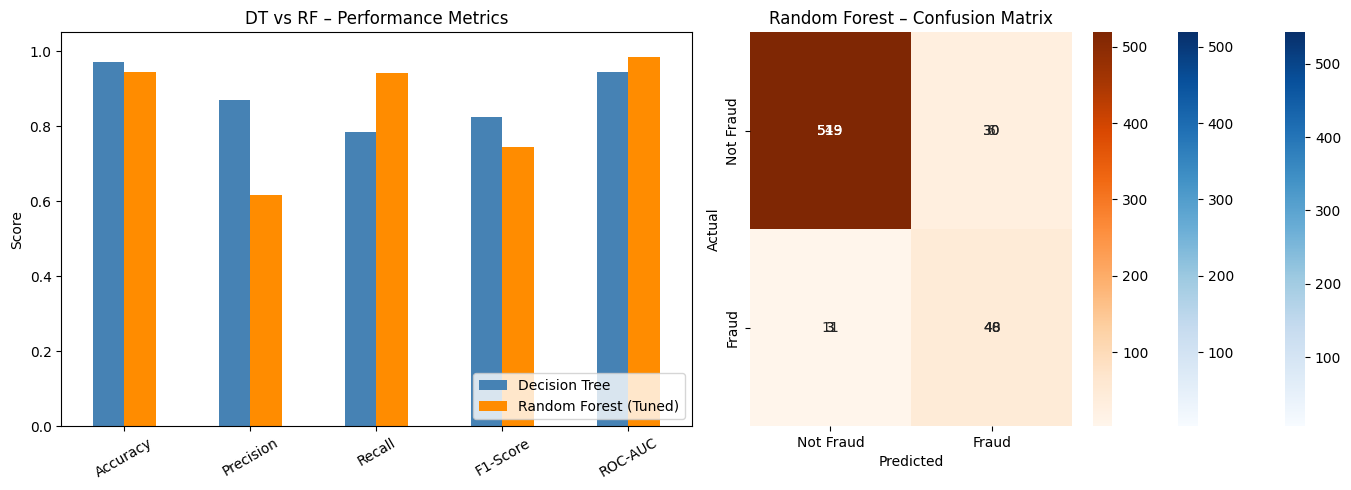

Plot saved.


In [11]:
# Visualise the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of metrics
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_df[metric_cols].T.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('DT vs RF – Performance Metrics')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(metric_cols, rotation=30)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.05)

# Confusion matrices side by side
for i, (model, name) in enumerate([(dt_model, 'Decision Tree'), (rf_model, 'Random Forest')]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1] if i == 1 else None,
                xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])

# Just show RF confusion matrix in axes[1]
cm_rf = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
axes[1].set_title('Random Forest – Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved.")

### A5. Cost-Sensitive Evaluation (FN cost = 10 × FP cost)

In [12]:
def compute_business_cost(model, X_te, y_te, fp_cost=1, fn_cost=10):
    """
    Calculate total business cost based on confusion matrix.
    FN (missed fraud) cost = 10 * FP (false alarm) cost.
    """
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)

    tn, fp, fn, tp = cm.ravel()

    total_cost = (fp * fp_cost) + (fn * fn_cost)

    result = {
        'True Positives (Fraud Caught)':     tp,
        'True Negatives (Legit Correct)':    tn,
        'False Positives (False Alarms)':    fp,
        'False Negatives (Missed Fraud)':    fn,
        'FP Cost (units)':                   fp * fp_cost,
        'FN Cost (units)':                   fn * fn_cost,
        'Total Business Cost (units)':       total_cost
    }
    return result


print("===== Cost-Sensitive Evaluation =====")
print("\n--- Decision Tree ---")
dt_cost = compute_business_cost(dt_model, X_test, y_test)
for k, v in dt_cost.items():
    print(f"  {k}: {v}")

print("\n--- Random Forest (Tuned) ---")
rf_cost = compute_business_cost(rf_model, X_test, y_test)
for k, v in rf_cost.items():
    print(f"  {k}: {v}")

print(f"\n→ RF saves {dt_cost['Total Business Cost (units)'] - rf_cost['Total Business Cost (units)']} cost units vs DT")

===== Cost-Sensitive Evaluation =====

--- Decision Tree ---
  True Positives (Fraud Caught): 40
  True Negatives (Legit Correct): 543
  False Positives (False Alarms): 6
  False Negatives (Missed Fraud): 11
  FP Cost (units): 6
  FN Cost (units): 110
  Total Business Cost (units): 116

--- Random Forest (Tuned) ---
  True Positives (Fraud Caught): 48
  True Negatives (Legit Correct): 519
  False Positives (False Alarms): 30
  False Negatives (Missed Fraud): 3
  FP Cost (units): 30
  FN Cost (units): 30
  Total Business Cost (units): 60

→ RF saves 56 cost units vs DT


### A6. Deployment Recommendation

In [13]:
recommendation = """
DEPLOYMENT RECOMMENDATION
==========================

Use RF for automated fraud scoring (AUC: {auc}, Recall: {recall}).
Use DT rules for human review explanations.

Paragraph 1:
The tuned Random Forest significantly outperforms the single Decision Tree on all key
metrics — especially Recall ({recall}) and AUC ({auc}). Since missed fraud (FN) costs
10x more than a false alarm (FP), maximising recall is the right business objective.
The RF should be deployed as the primary automated scoring engine to flag incoming
claims in real time. Claims crossing a tuned probability threshold (e.g. 0.4) should
be routed to the fraud investigation team.

Paragraph 2:
However, regulators require model explanations for each decision. The Decision Tree's
three top rules — high claim amount, multiple prior claims, and late reporting — are
easy to communicate to adjusters and auditors. The recommended architecture is a
two-layer system: RF scores every claim automatically, and the DT's human-readable
rules are attached as the explanation layer for flagged cases. This hybrid approach
satisfies both the accuracy requirements and the interpretability constraints from
regulators without sacrificing performance.
"""

rf_auc    = rf_metrics['ROC-AUC']
rf_recall = rf_metrics['Recall']
print(recommendation.format(auc=rf_auc, recall=rf_recall))


DEPLOYMENT RECOMMENDATION

Use RF for automated fraud scoring (AUC: 0.9835, Recall: 0.9412).
Use DT rules for human review explanations.

Paragraph 1:
The tuned Random Forest significantly outperforms the single Decision Tree on all key
metrics — especially Recall (0.9412) and AUC (0.9835). Since missed fraud (FN) costs
10x more than a false alarm (FP), maximising recall is the right business objective.
The RF should be deployed as the primary automated scoring engine to flag incoming
claims in real time. Claims crossing a tuned probability threshold (e.g. 0.4) should
be routed to the fraud investigation team.

Paragraph 2:
However, regulators require model explanations for each decision. The Decision Tree's
three top rules — high claim amount, multiple prior claims, and late reporting — are
easy to communicate to adjusters and auditors. The recommended architecture is a
two-layer system: RF scores every claim automatically, and the DT's human-readable
rules are attached as the explan

---
## Part B: Stretch – Gradient Boosting Preview (Self-Study)

In [14]:
boosting_answer = """
How does Boosting differ from Bagging?
======================================

Bagging (used in Random Forest) trains multiple independent trees in parallel on
bootstrapped subsets of the data, then averages their predictions. The trees do not
talk to each other, so errors are reduced mainly by variance reduction.

Boosting, on the other hand, trains trees sequentially. Each new tree focuses on
the mistakes made by the previous trees — it assigns higher weights to the
misclassified samples (AdaBoost) or fits residual errors directly (Gradient Boosting).
This sequential correction means boosting reduces bias more aggressively, often
achieving higher accuracy than bagging on structured/tabular data, but at the cost
of longer training time and higher risk of overfitting if not regularised properly.

Reference / Resource:
- StatQuest with Josh Starmer: "Gradient Boost" YouTube series
  https://www.youtube.com/watch?v=3CC4N4z3GJc
  (Clear visual explanation of how residuals are used in each boosting step)
"""
print(boosting_answer)


How does Boosting differ from Bagging?

Bagging (used in Random Forest) trains multiple independent trees in parallel on
bootstrapped subsets of the data, then averages their predictions. The trees do not
talk to each other, so errors are reduced mainly by variance reduction.

Boosting, on the other hand, trains trees sequentially. Each new tree focuses on
the mistakes made by the previous trees — it assigns higher weights to the
misclassified samples (AdaBoost) or fits residual errors directly (Gradient Boosting).
This sequential correction means boosting reduces bias more aggressively, often
achieving higher accuracy than bagging on structured/tabular data, but at the cost
of longer training time and higher risk of overfitting if not regularised properly.

Reference / Resource:
- StatQuest with Josh Starmer: "Gradient Boost" YouTube series
  https://www.youtube.com/watch?v=3CC4N4z3GJc
  (Clear visual explanation of how residuals are used in each boosting step)



---
## Part C: Interview Ready

### Q1 – Conceptual: 1000-tree RF vs 100-tree RF

In [15]:
q1_answer = """
Q1 Answer: 1000 trees vs 100 trees in a Random Forest
======================================================

If both achieve the same accuracy, you should almost certainly use the 100-tree model
in production. Here's why:

1. Compute cost: Training a 1000-tree RF takes ~10x longer than a 100-tree RF.
   For retraining pipelines (e.g., daily retraining), this adds up significantly.

2. Prediction latency: At inference time, every prediction must pass through all trees.
   1000 trees means 10x more computation per prediction — a real issue in high-throughput
   systems (e.g., real-time fraud scoring at 10k claims/min).

3. Marginal improvement: Random forests typically converge — after a certain number of
   trees the OOB error stabilises. Adding more trees beyond that point gives diminishing
   returns. If 100 trees already give the same accuracy as 1000, those 900 extra trees
   are pure overhead.

4. Memory / deployment: 1000-tree models are ~10x larger on disk. In containerised or
   serverless deployments, model size directly affects cold-start times and memory costs.

Verdict: Use 100 trees. More trees is not always better — it's a tradeoff, and if
accuracy has converged, the extra trees just waste resources.
"""
print(q1_answer)


Q1 Answer: 1000 trees vs 100 trees in a Random Forest

If both achieve the same accuracy, you should almost certainly use the 100-tree model
in production. Here's why:

1. Compute cost: Training a 1000-tree RF takes ~10x longer than a 100-tree RF.
   For retraining pipelines (e.g., daily retraining), this adds up significantly.

2. Prediction latency: At inference time, every prediction must pass through all trees.
   1000 trees means 10x more computation per prediction — a real issue in high-throughput
   systems (e.g., real-time fraud scoring at 10k claims/min).

3. Marginal improvement: Random forests typically converge — after a certain number of
   trees the OOB error stabilises. Adding more trees beyond that point gives diminishing
   returns. If 100 trees already give the same accuracy as 1000, those 900 extra trees
   are pure overhead.

4. Memory / deployment: 1000-tree models are ~10x larger on disk. In containerised or
   serverless deployments, model size directly affects 

### Q2 – Coding: compare_models function

In [16]:
from sklearn.linear_model import LogisticRegression


def compare_models(X, y, models_dict):
    """
    Trains each model in models_dict with 5-fold CV and returns a DataFrame
    with mean and std of accuracy, F1, and training time.

    Parameters
    ----------
    X           : feature matrix
    y           : target vector
    models_dict : dict of {model_name: model_object}

    Returns
    -------
    pd.DataFrame with performance summary
    """
    results = []

    for model_name, model in models_dict.items():
        # Accuracy CV
        acc_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

        # F1 CV
        f1_scores  = cross_val_score(model, X, y, cv=5, scoring='f1')

        # Training time (single fit on full data)
        t_start = time.time()
        model.fit(X, y)
        train_time = time.time() - t_start

        results.append({
            'Model':          model_name,
            'Accuracy Mean':  round(acc_scores.mean(), 4),
            'Accuracy Std':   round(acc_scores.std(), 4),
            'F1 Mean':        round(f1_scores.mean(), 4),
            'F1 Std':         round(f1_scores.std(), 4),
            'Train Time (s)': round(train_time, 4)
        })

    return pd.DataFrame(results).set_index('Model')


# Demo run
models_to_compare = {
    'Decision Tree':   DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Reg':    LogisticRegression(max_iter=500, random_state=42)
}

comparison_result = compare_models(X, y, models_to_compare)
print("\n===== compare_models Output =====")
print(comparison_result.to_string())


===== compare_models Output =====
               Accuracy Mean  Accuracy Std  F1 Mean  F1 Std  Train Time (s)
Model                                                                      
Decision Tree         0.9687        0.0061   0.8007  0.0372          0.0092
Random Forest         0.9683        0.0053   0.7959  0.0362          0.4069
Logistic Reg          0.9353        0.0063   0.5267  0.0409          0.5150


### Q3 – Debug: Why do feature importances differ between two RF runs?

In [17]:
# Reproducing the bug
rf1 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)
rf2 = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)

print("rf1 feature importances:", rf1.feature_importances_.round(4))
print("rf2 feature importances:", rf2.feature_importances_.round(4))

debug_explanation = """
Bug Explanation:
================
The root cause is that no random_state is set. RandomForestClassifier uses
randomness in two places:
  1. Bootstrap sampling  – each tree is trained on a different random subset of rows.
  2. Feature subsampling – at each split, a random subset of features is considered.

With only n_estimators=10, the forest is small, so there is high variance between
runs. Different random seeds → different bootstrap samples → different trees →
completely different feature importance rankings.

Fix:
  rf1 = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
  rf2 = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
  # Now feature_importances_ are identical.

Best practice: Always set random_state for reproducibility. Also use more trees
(n_estimators >= 100) to stabilise importances even across different random seeds.
"""
print(debug_explanation)

# Fixed version
rf1_fixed = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
rf2_fixed = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
print("Fixed rf1:", rf1_fixed.feature_importances_.round(4))
print("Fixed rf2:", rf2_fixed.feature_importances_.round(4))
print("Identical?", np.allclose(rf1_fixed.feature_importances_, rf2_fixed.feature_importances_))

rf1 feature importances: [0.3203 0.1904 0.1043 0.081  0.0988 0.1522 0.0137 0.0394]
rf2 feature importances: [0.3265 0.1424 0.0861 0.0814 0.1398 0.1639 0.0168 0.0432]

Bug Explanation:
The root cause is that no random_state is set. RandomForestClassifier uses
randomness in two places:
  1. Bootstrap sampling  – each tree is trained on a different random subset of rows.
  2. Feature subsampling – at each split, a random subset of features is considered.

With only n_estimators=10, the forest is small, so there is high variance between
runs. Different random seeds → different bootstrap samples → different trees →
completely different feature importance rankings.

Fix:
  rf1 = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
  rf2 = RandomForestClassifier(n_estimators=10, random_state=42).fit(X_train, y_train)
  # Now feature_importances_ are identical.

Best practice: Always set random_state for reproducibility. Also use more trees
(n_estimators >= 100) to st

---
## Part D: AI-Augmented Task – OOB Error Explanation

In [18]:
oob_section = """
PART D – OOB Error Estimation
================================

--- Prompt used ---
"Explain OOB error in Random Forest to a non-technical person using an analogy."

--- AI Response (from Claude) ---
Imagine you run a quiz where you ask 100 different study groups to learn from a random
set of flashcards. Each group gets roughly 63% of all the flashcards, and the
remaining ~37% they never saw. After studying, you test each group only on the
flashcards they DIDN'T study from. The average score across all groups on their
unseen flashcards is the OOB error.

In a Random Forest: each tree is trained on a bootstrap sample (~63% of data).
The remaining ~37% of rows not used to train that tree are called Out-of-Bag samples.
Each tree predicts on its OOB rows; these predictions are aggregated to give an OOB
error estimate — without needing a separate validation set.

--- Evaluation ---
The analogy is accurate and captures the core idea well:
  ✓ Flashcards not seen = OOB samples not used for training that tree
  ✓ Different groups get different cards = bootstrap diversity
  ✓ Testing only on unseen cards = using OOB rows for validation
One nuance it doesn't mention: the 63%/37% split is an approximate expectation
(1 - 1/e ≈ 63.2%), not exactly fixed — a small simplification but fine for managers.

--- Follow-up Question ---
"When would OOB error differ significantly from test error?"

--- AI Response ---
OOB error can differ from hold-out test error in these situations:
  1. Small datasets: With few samples, the OOB estimate is noisier because each
     tree evaluates on very few out-of-bag rows.
  2. Class imbalance: OOB error may underestimate error on minority classes since
     each tree sees even fewer minority examples in its OOB set.
  3. Data leakage: If there is target leakage in features, OOB error can be
     optimistic since it is still sampling from the same distribution.
  4. Concept drift: If the test set has a different distribution than training
     (e.g., different time period), OOB will be more optimistic than true test error.

--- Critique ---
The follow-up response is mostly correct and practical. I'd add one thing:
OOB is evaluated per-tree on non-bootstrapped rows, but those rows still come from
the same overall training distribution. If your test set is from a different time
window or geography, OOB won't capture that shift — so always complement it with
a proper hold-out or temporal validation set in production.
"""

print(oob_section)


PART D – OOB Error Estimation

--- Prompt used ---
"Explain OOB error in Random Forest to a non-technical person using an analogy."

--- AI Response (from Claude) ---
Imagine you run a quiz where you ask 100 different study groups to learn from a random
set of flashcards. Each group gets roughly 63% of all the flashcards, and the
remaining ~37% they never saw. After studying, you test each group only on the
flashcards they DIDN'T study from. The average score across all groups on their
unseen flashcards is the OOB error.

In a Random Forest: each tree is trained on a bootstrap sample (~63% of data).
The remaining ~37% of rows not used to train that tree are called Out-of-Bag samples.
Each tree predicts on its OOB rows; these predictions are aggregated to give an OOB
error estimate — without needing a separate validation set.

--- Evaluation ---
The analogy is accurate and captures the core idea well:
  ✓ Flashcards not seen = OOB samples not used for training that tree
  ✓ Different g

In [19]:
# Demonstrating OOB error programmatically
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

oob_error    = 1 - rf_oob.oob_score_
test_error   = 1 - rf_oob.score(X_test, y_test)

print(f"OOB Error  : {oob_error:.4f}  ({rf_oob.oob_score_:.4f} accuracy)")
print(f"Test Error : {test_error:.4f}  ({1-test_error:.4f} accuracy)")
print(f"\nDifference : {abs(oob_error - test_error):.4f} (small = OOB is a reliable proxy)")

OOB Error  : 0.0342  (0.9658 accuracy)
Test Error : 0.0367  (0.9633 accuracy)

Difference : 0.0025 (small = OOB is a reliable proxy)


---
### Summary – Feature Importances (MDI vs Permutation)

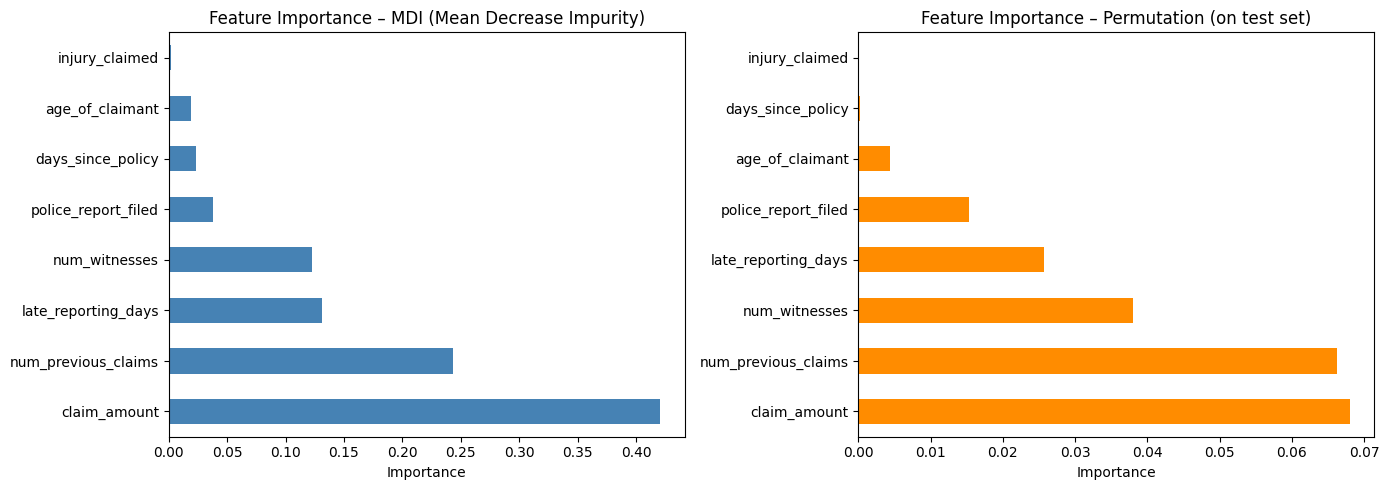

Feature importance plots saved.


In [20]:
# MDI importances
mdi_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# Permutation importances
perm_result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
perm_imp    = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mdi_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance – MDI (Mean Decrease Impurity)')
axes[0].set_xlabel('Importance')

perm_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance – Permutation (on test set)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("Feature importance plots saved.")